# 02 — MBA-Relevant Occupation Analysis

Narrowing the full H-1B/PERM dataset down to roles an MBA graduate can realistically target,
and starting to answer the recruiting-strategy questions: which employers, which functions,
which locations give an international MBA the best odds of sponsorship.

**Important caveat**: neither disclosure file includes a minimum-degree-required field (PERM's
public extract only has `OCCUPATION_TYPE`: Professional / Non-professional / College-University
Teacher — it drops the more detailed education fields DOL collects internally). So "MBA-relevant"
here is a SOC-code + title heuristic (see `src/mba_occupations.py`), not a hard filter on actual
degree requirements. Treat tier splits as directional, not exact.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data_loader import load_lca, load_perm, annual_wage  # noqa: E402
from mba_occupations import classify_mba_relevance  # noqa: E402

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
FIG_DIR = Path.cwd().parent / "outputs" / "figures"

In [2]:
lca = load_lca()
perm = load_perm()

lca["MBA_TIER"] = classify_mba_relevance(lca["SOC_CODE"], lca["SOC_TITLE"])
perm["MBA_TIER"] = classify_mba_relevance(perm["PWD_SOC_CODE"], perm["PWD_SOC_TITLE"])

## How much of the market is actually MBA-relevant?

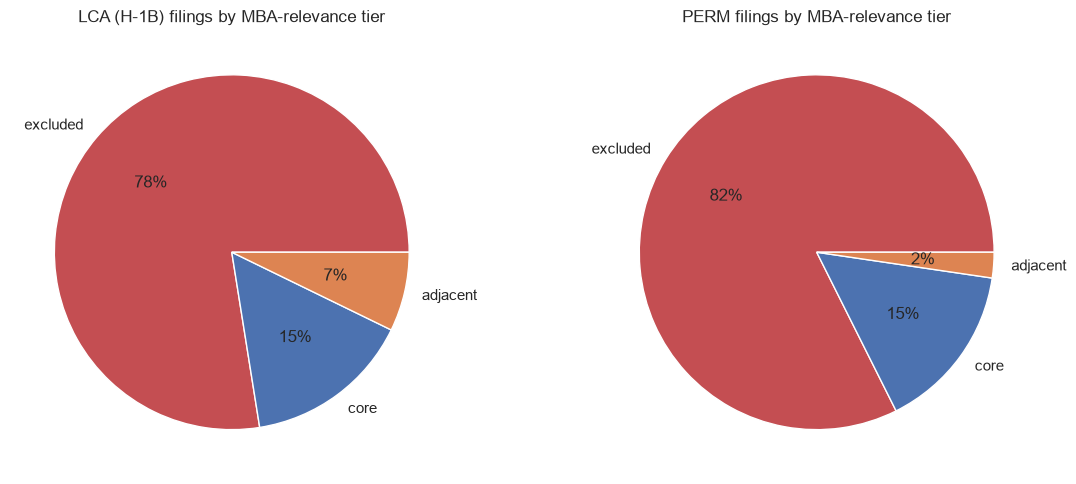

LCA:
 MBA_TIER
excluded    339137
core         66781
adjacent     31578
Name: count, dtype: int64 

PERM:
 MBA_TIER
excluded    92725
core        17207
adjacent     2618
Name: count, dtype: int64


In [3]:
lca_tier_counts = lca["MBA_TIER"].value_counts()
perm_tier_counts = perm["MBA_TIER"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lca_tier_counts.plot.pie(ax=axes[0], autopct="%1.0f%%", ylabel="", colors=["#C44E52", "#4C72B0", "#DD8452"])
axes[0].set_title("LCA (H-1B) filings by MBA-relevance tier")
perm_tier_counts.plot.pie(ax=axes[1], autopct="%1.0f%%", ylabel="", colors=["#C44E52", "#4C72B0", "#DD8452"])
axes[1].set_title("PERM filings by MBA-relevance tier")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_mba_tier_share.png", dpi=150)
plt.show()

print("LCA:\n", lca_tier_counts, "\n")
print("PERM:\n", perm_tier_counts)

In [4]:
lca_mba = lca[lca["MBA_TIER"] != "excluded"].copy()
perm_mba = perm[perm["MBA_TIER"] != "excluded"].copy()
print(f"MBA-relevant LCA filings: {len(lca_mba):,} ({len(lca_mba) / len(lca):.1%} of all)")
print(f"MBA-relevant PERM filings: {len(perm_mba):,} ({len(perm_mba) / len(perm):.1%} of all)")

MBA-relevant LCA filings: 98,359 (22.5% of all)
MBA-relevant PERM filings: 19,825 (17.6% of all)


## Certification rate: does it differ by tier?

If core/adjacent roles get certified at a similar (or better) rate than the broader market,
that's reassuring — it means the bottleneck for MBAs isn't the process, it's finding
employers who file for these roles at all.

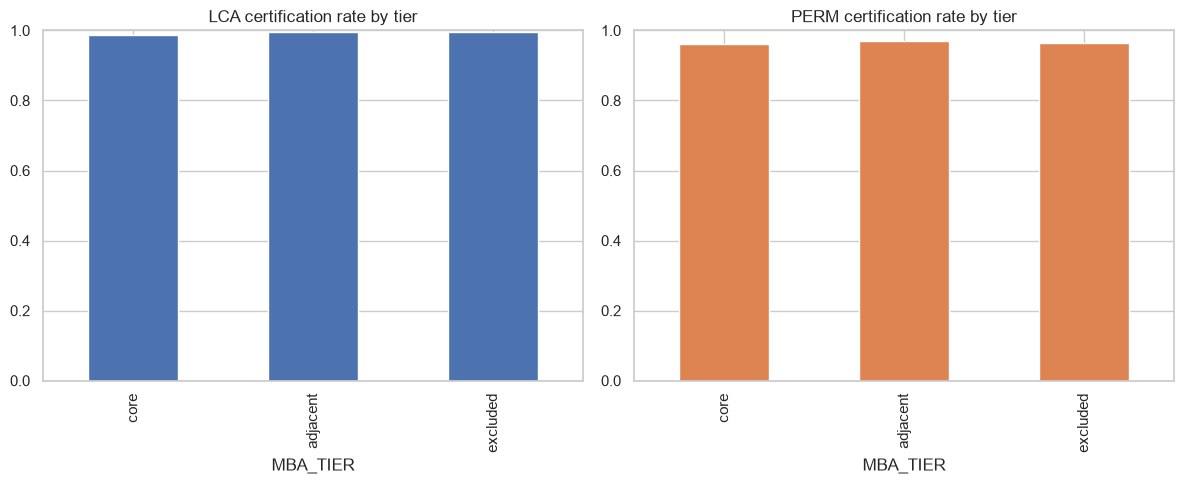

In [5]:
def cert_rate_by_tier(df, decided_statuses, denied_status="Denied"):
    decided = df[df["CASE_STATUS"].isin(decided_statuses)]
    return decided.groupby("MBA_TIER")["CASE_STATUS"].apply(lambda s: (s != denied_status).mean())


lca_cert_by_tier = cert_rate_by_tier(lca, ["Certified", "Certified - Withdrawn", "Denied"])
perm_cert_by_tier = cert_rate_by_tier(perm, ["Certified", "Certified - Expired", "Denied"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lca_cert_by_tier.reindex(["core", "adjacent", "excluded"]).plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("LCA certification rate by tier")
axes[0].set_ylim(0, 1)
perm_cert_by_tier.reindex(["core", "adjacent", "excluded"]).plot.bar(ax=axes[1], color="#DD8452")
axes[1].set_title("PERM certification rate by tier")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_cert_rate_by_tier.png", dpi=150)
plt.show()

## Which functions within "core" and "adjacent" see the most volume?

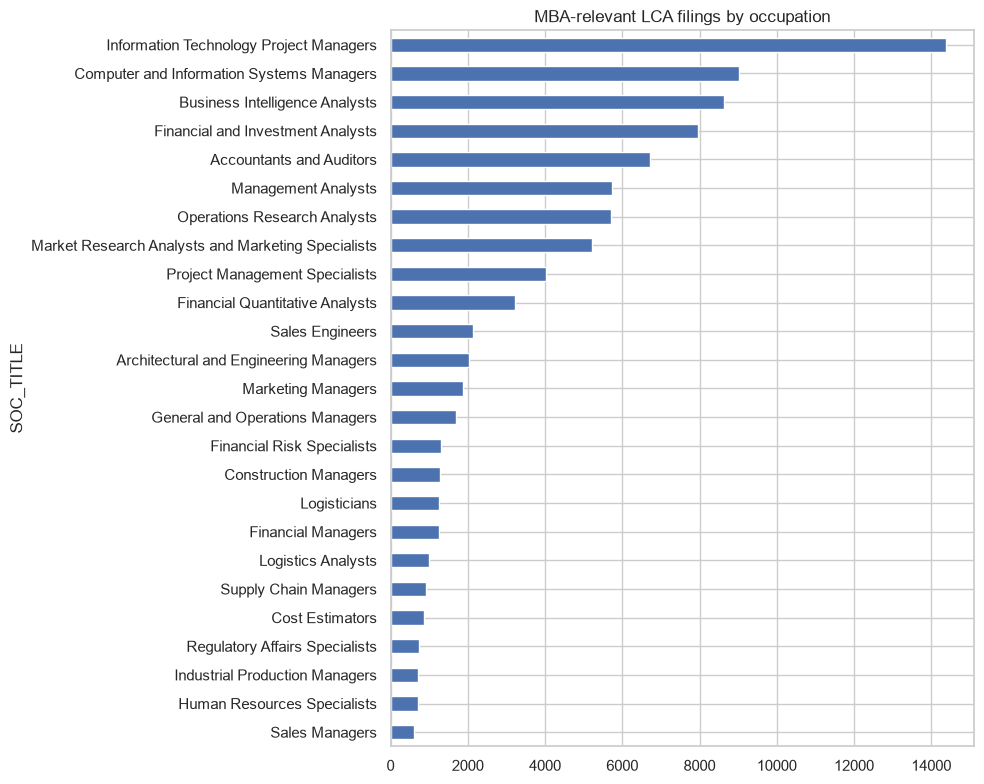

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
lca_mba["SOC_TITLE"].value_counts().head(25).sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_title("MBA-relevant LCA filings by occupation")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_mba_occupations_lca.png", dpi=150)
plt.show()

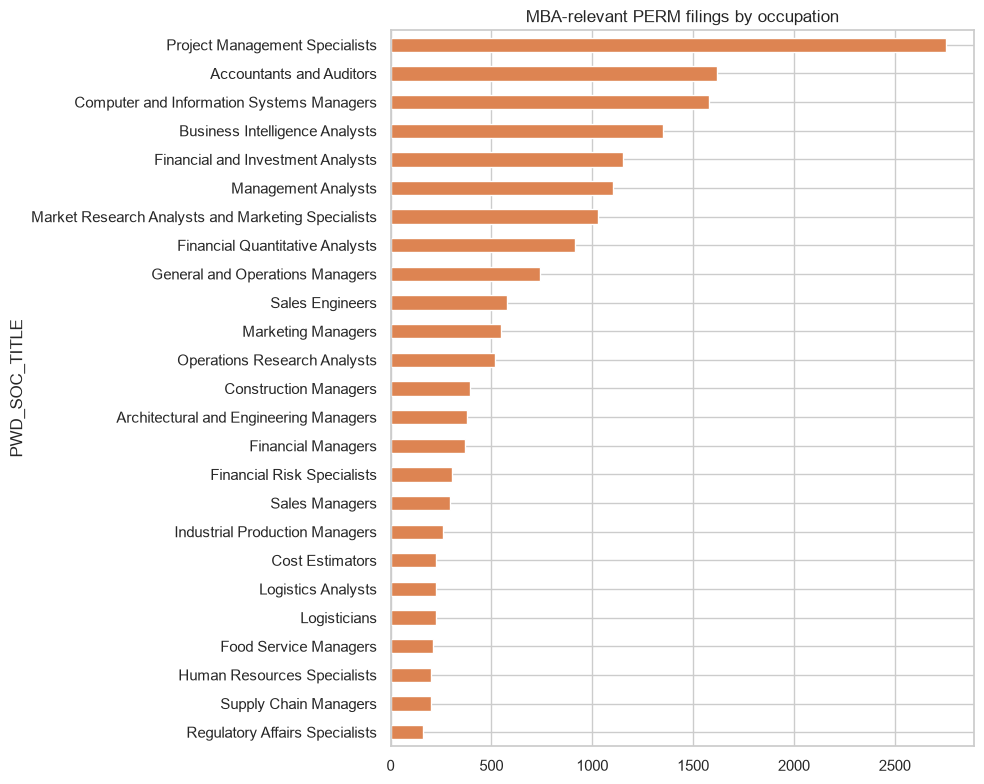

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
perm_mba["PWD_SOC_TITLE"].value_counts().head(25).sort_values().plot.barh(ax=ax, color="#DD8452")
ax.set_title("MBA-relevant PERM filings by occupation")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_mba_occupations_perm.png", dpi=150)
plt.show()

## Top employers sponsoring MBA-relevant roles

This is the recruiting-strategy payload: which companies are actually filing for business/
management-track roles (as opposed to being a huge H-1B filer purely on the engineering side).

In [8]:
top_employers_lca_mba = lca_mba["EMPLOYER_NAME"].value_counts().head(30)
top_employers_lca_mba

EMPLOYER_NAME
Amazon.com Services LLC                         4565
Ernst & Young U.S. LLP                          3086
INFOSYS LIMITED                                 1501
JPMorgan Chase & Co.                            1160
Google LLC                                      1123
Apple Inc.                                       959
Microsoft Corporation                            837
GOLDMAN SACHS & CO. LLC                          782
TT Commerce & Global Services LLC                772
Meta Platforms, Inc                              613
Tesla, Inc.                                      609
Deloitte Tax LLP                                 601
Deloitte & Touche LLP                            551
WAL-MART ASSOCIATES, INC.                        548
Boston Consulting Group, Inc.                    543
Deloitte Consulting LLP                          540
HCL AMERICA INC                                  477
Amazon Web Services, Inc.                        475
COGNIZANT TECHNOLOGY SOLUTIONS U

In [9]:
top_employers_perm_mba = perm_mba["EMP_BUSINESS_NAME"].value_counts().head(30)
top_employers_perm_mba

EMP_BUSINESS_NAME
Ernst & Young U.S. LLP                          342
Deloitte Consulting LLP                         308
Microsoft Corporation                           270
JPMORGAN CHASE & CO.                            200
MCKINSEY & COMPANY, INC. UNITED STATES          177
Goldman Sachs & Co. LLC                         174
THE BOSTON CONSULTING GROUP, INC.               142
Citibank, N.A.                                  132
WAL-MART ASSOCIATES, INC.                       130
ByteDance Inc.                                  111
Accenture LLP                                   109
Salesforce, Inc.                                101
Uber Technologies, Inc.                          81
NVIDIA Corporation                               79
Cisco Systems, Inc.                              72
Tesla, Inc.                                      70
Deloitte Tax LLP                                 68
BAIN & COMPANY, INC.                             59
ServiceNow, Inc.                              

### "MBA-focused" employers: high share of MBA-relevant filings, not just high volume

A employer with 5 total filings, all core-MBA roles, is a better lead than one with 500
filings where only 2% are business-track. Rank by volume *and* mix.

In [10]:
def employer_mba_mix(df, employer_col, min_filings=10):
    g = df.groupby(employer_col)["MBA_TIER"].agg(
        total="count",
        mba_relevant=lambda s: (s != "excluded").sum(),
    )
    g["mba_share"] = g["mba_relevant"] / g["total"]
    return g[g["total"] >= min_filings].sort_values(["mba_share", "total"], ascending=False)


lca_employer_mix = employer_mba_mix(lca, "EMPLOYER_NAME")
lca_employer_mix.head(25)

,total,mba_relevant,mba_share
EMPLOYER_NAME,,,
"MANHATTAN ASSOCIATES, INC.",103,103,1.0
Moelis & Company Group LP,59,59,1.0
"A.T. Kearney, Inc.",48,48,1.0
"Standish Management US, LLC",42,42,1.0
"SCOTIA CAPITAL (USA), INC.",40,40,1.0
Inrika Inc,31,31,1.0
Newton Consulting Inc.,30,30,1.0
"Houlihan Lokey Financial Advisors, Inc.",26,26,1.0
Santander U.S. Capital Markets LLC,26,26,1.0


In [11]:
perm_employer_mix = employer_mba_mix(perm, "EMP_BUSINESS_NAME")
perm_employer_mix.head(25)

,total,mba_relevant,mba_share
EMP_BUSINESS_NAME,,,
"MCKINSEY & COMPANY, INC. UNITED STATES",177,177,1.000000
EVERCORE PARTNERS SERVICES EAST LLC,21,21,1.000000
"BDO USA, P.C.",19,19,1.000000
"Cubist Systematic Strategies, LLC",15,15,1.000000
UBS Securities LLC,15,15,1.000000
Bank of China,11,11,1.000000
"BAKER TILLY ADVISORY GROUP, LP",10,10,1.000000
"Mediterranean Shipping Company (USA), Inc.",10,10,1.000000
PwC US Tax LLP,29,28,0.965517


## Wage premium for MBA-relevant roles

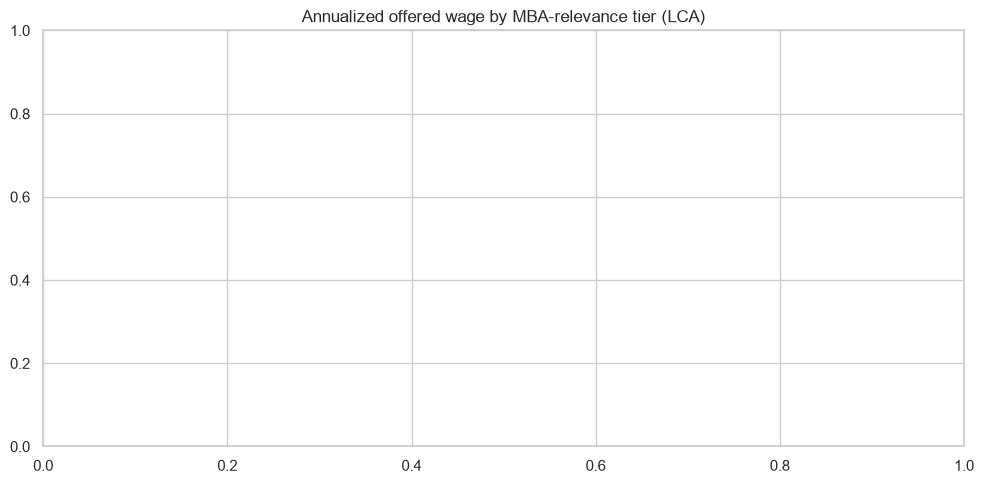

,count,mean,std,min,25%,50%,75%,max


In [12]:
lca["ANNUAL_WAGE_FROM"] = annual_wage(lca["WAGE_RATE_OF_PAY_FROM"], lca["WAGE_UNIT_OF_PAY"])
lca_wage = lca[(lca["ANNUAL_WAGE_FROM"] > 20_000) & (lca["ANNUAL_WAGE_FROM"] < 500_000)]

fig, ax = plt.subplots()
sns.boxplot(data=lca_wage, x="MBA_TIER", y="ANNUAL_WAGE_FROM", order=["core", "adjacent", "excluded"], ax=ax)
ax.set_title("Annualized offered wage by MBA-relevance tier (LCA)")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_wage_by_tier.png", dpi=150)
plt.show()

lca_wage.groupby("MBA_TIER")["ANNUAL_WAGE_FROM"].describe()

## Geographic concentration of MBA-relevant sponsorship

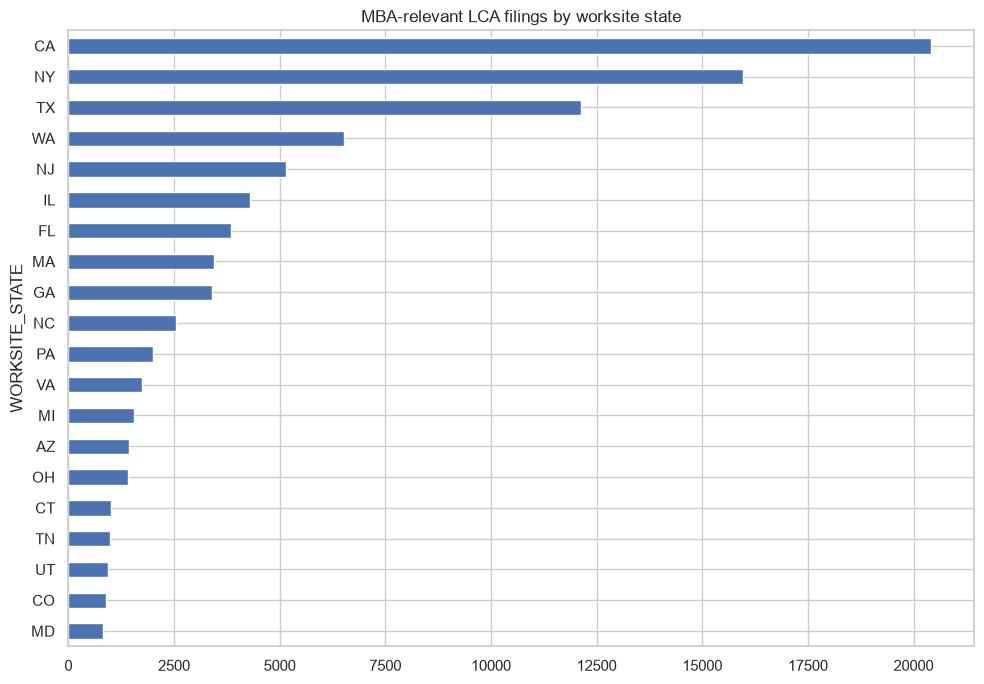

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))
lca_mba["WORKSITE_STATE"].value_counts().head(20).sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_title("MBA-relevant LCA filings by worksite state")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_mba_states.png", dpi=150)
plt.show()

## Save dashboard-ready aggregates

In [14]:
lca_employer_mix.reset_index().to_csv(PROCESSED_DIR / "lca_employer_mba_mix.csv", index=False)
perm_employer_mix.reset_index().to_csv(PROCESSED_DIR / "perm_employer_mba_mix.csv", index=False)
lca_mba["SOC_TITLE"].value_counts().rename("filings").to_csv(PROCESSED_DIR / "lca_mba_occupations.csv")
perm_mba["PWD_SOC_TITLE"].value_counts().rename("filings").to_csv(PROCESSED_DIR / "perm_mba_occupations.csv")
lca_mba["WORKSITE_STATE"].value_counts().rename("filings").to_csv(PROCESSED_DIR / "lca_mba_states.csv")

print("Saved MBA-focused aggregates to", PROCESSED_DIR)

Saved MBA-focused aggregates to /Users/jaime/Local Documents/GitHub/h1b_analysis/data/processed


## Notes for next session

- Need a better MBA-relevance signal than SOC/title regex — worth checking whether the DOL
  PERM *case-level* disclosure (not this summary extract) exposes minimum education fields we
  could join in, or whether O*NET's "typical education" lookup by SOC code is a cleaner proxy.
- Should link LCA employer names to PERM employer names (fuzzy match — names aren't identical
  across the two systems) to see which employers do *both* H-1B and green card sponsorship for
  business roles, since that end-to-end path is what students actually care about.
- Consider NAICS industry rollups on top of the occupation tiers (e.g. consulting/finance/tech
  sector cuts) for the dashboard's employer targeting view.